<a href="https://colab.research.google.com/github/marina-popova11/MambaModelPrediction/blob/train/mamba_3clases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch
!pip install pandas numpy scikit-learn tqdm torch matplotlib
!pip install mamba-ssm --no-build-isolation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import pickle
import os

In [26]:
import pandas as pd
import numpy as np

def create_features(df, lookback=24, norm_window=24):
    """Создание признаков для временного ряда
    Вход: Log-Return + Z-score
    Выход: Log-Return (будущий)"""
    df = df.copy()

    df['returns'] = df['Close'].pct_change()
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

    rolling_mean = df['log_return'].rolling(window=norm_window).mean()
    rolling_std = df['log_return'].rolling(window=norm_window).std()
    df['norm_return'] = (df['log_return'] - rolling_mean) / (rolling_std + 1e-9)

    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'norm_return_lag_{lag}'] = df['norm_return'].shift(lag)

    df['norm_return_sma_12'] = df['norm_return'].rolling(12).mean()
    df['norm_return_sma_24'] = df['norm_return'].rolling(24).mean()
    df['norm_return_ema_12'] = df['norm_return'].ewm(span=12).mean()

    df['volatility_returns'] = df['returns'].rolling(window=lookback).std()
    df['volatility_log'] = df['log_return'].rolling(window=lookback).std()
    df['rsi'] = compute_rsi_stable(df['log_return'], period=14)

    long_vol = df['log_return'].rolling(window=lookback*3).std()
    df['vol_ratio'] = df['volatility_log'] / (long_vol + 1e-9)

    for lag in [1, 2, 3]:
        df[f'log_return_lag_{lag}'] = df['log_return'].shift(lag)

    forecast_horizon = 24
    future_close = df['Close'].shift(-forecast_horizon)
    current_close = df['Close']
    df['target_return'] = np.log(future_close / current_close.shift(-1))
    df['target_direction'] = (df['target_return'] > 0).astype(int)

    df['volume_ma'] = df['Volume'].rolling(24).mean()
    df['volume_ratio'] = df['Volume'] / (df['volume_ma'] + 1e-9)

    vol_rolling_mean = df['Volume'].rolling(window=norm_window).mean()
    vol_rolling_std = df['Volume'].rolling(window=norm_window).std()
    df['volume_norm'] = (df['Volume'] - vol_rolling_mean) / (vol_rolling_std + 1e-9)

    df.dropna(inplace=True)
    return df

def compute_rsi_stable(prices, period=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).ewm(alpha=1/period, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def create_discrete_targets_threshold(df, target_col='target_return', vol_col='volatility_log'):
    """Дискретизация по квантилям — в каждом бине равное количество токенов"""
    df = df.copy()

    threshold = df[vol_col].median() * 0.5  # или фиксированный: 0.003 (0.3%)

    conditions = [
        df[target_col] < -threshold,      # down
        df[target_col] > threshold,       # up
    ]
    choices = ['down', 'up']

    df['target_class'] = np.select(conditions, choices, default='neutral')
    df['target_class'] = df['target_class'].astype('category')

    print(f"\n3-class distribution:")
    print(df['target_class'].value_counts(normalize=True))

    return df

In [27]:
import pandas as pd
df = pd.read_csv("btc_1h_data_2020-2025.csv")
print(df.shape, df.columns)
print(df.head(5))

(51926, 12) Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')
                   Open time     Open     High      Low    Close      Volume  \
0  2020-01-01 00:00:00+00:00  7195.24  7196.25  7175.46  7177.02  511.814901   
1  2020-01-01 01:00:00+00:00  7176.47  7230.00  7175.71  7216.27  883.052603   
2  2020-01-01 02:00:00+00:00  7215.52  7244.87  7211.41  7242.85  655.156809   
3  2020-01-01 03:00:00+00:00  7242.66  7245.00  7220.00  7225.01  783.724867   
4  2020-01-01 04:00:00+00:00  7225.00  7230.00  7215.03  7217.27  467.812578   

                  Close time  Quote asset volume  Number of trades  \
0  2020-01-01 01:00:00+00:00        3.675857e+06              7640   
1  2020-01-01 02:00:00+00:00        6.365953e+06              9033   
2  2020-01-01 03:00:00+00:00        4.736719e+06              7466   

In [28]:
new_df = create_features(df)
df_with_classes = create_discrete_targets_threshold(new_df)
print(new_df.shape, new_df.columns)
print(new_df.head(5))
target_clean = df_with_classes['target_return'].clip(
    lower=df_with_classes['target_return'].quantile(0.01),
    upper=df_with_classes['target_return'].quantile(0.99)
)
print("\nМедианная доходность по классам:")
print(df_with_classes.groupby('target_class')['target_return'].median())
print(df_with_classes.head(5))


3-class distribution:
target_class
up         0.463670
down       0.416072
neutral    0.120259
Name: proportion, dtype: float64
(51830, 36) Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore', 'returns', 'log_return',
       'norm_return', 'norm_return_lag_1', 'norm_return_lag_2',
       'norm_return_lag_3', 'norm_return_lag_6', 'norm_return_lag_12',
       'norm_return_lag_24', 'norm_return_sma_12', 'norm_return_sma_24',
       'norm_return_ema_12', 'volatility_returns', 'volatility_log', 'rsi',
       'vol_ratio', 'log_return_lag_1', 'log_return_lag_2', 'log_return_lag_3',
       'target_return', 'target_direction', 'volume_ma', 'volume_ratio',
       'volume_norm'],
      dtype='object')
                    Open time     Open     High      Low    Close  \
72  2020-01-04 00:00:00+00:00  7345.00  7350.00  7289.98  7302.24   
73  2020-

/tmp/ipykernel_7885/3480630478.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_with_classes.groupby('target_class')['target_return'].median())


In [29]:
df_with_classes.to_csv("btc_1h_2020-2025_training_sample_with_bins_second.csv", index=False)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_data_internal(df, lookback=60, n_bins=3, classification_mode=True):
    df = df.sort_values('Open time').reset_index(drop=True)
    df['Open time'] = pd.to_datetime(df['Open time'])
    if classification_mode:
        if 'target_class' not in df.columns:
            raise ValueError("Колонка 'target_class' не найдена. Запустите сначала create_discrete_targets_quantile.")

        target_col_raw = 'target_class'

        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df['target_encoded'] = le.fit_transform(df[target_col_raw])
        print("LabelEncoder classes order:")
        for i, cls in enumerate(le.classes_):
            print(f"  {i} → {cls}")

        target_col = 'target_encoded'
        class_labels = list(le.classes_) # Сохраняем порядок классов: ['neutral', 'strong_down'...]

        class_medians = df.groupby(target_col)['target_return'].median().to_dict()
        print(f"\nClass medians: {class_medians}")
    else:
        target_col = 'target_return'
        class_labels = None
        class_medians = None

    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
        'Taker buy quote asset volume', 'returns', 'log_return',
        'norm_return', 'norm_return_lag_1', 'norm_return_lag_2',
        'norm_return_lag_3', 'norm_return_lag_6', 'norm_return_lag_12',
        'norm_return_lag_24', 'norm_return_sma_12', 'norm_return_sma_24',
        'norm_return_ema_12', 'volatility_returns', 'volatility_log', 'rsi',
        'vol_ratio', 'log_return_lag_1', 'log_return_lag_2', 'log_return_lag_3',
        'volume_ma', 'volume_ratio', 'volume_norm'
    ]

    feature_cols = [col for col in feature_cols if col in df.columns]

    df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

    total_len = len(df)
    train_end = int(total_len * 0.70)
    val_end = int(total_len * 0.85)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    print("\n=== DATE RANGE CHECK ===")
    for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"{name}: {split_df['Open time'].min()} to {split_df['Open time'].max()}")

    if train_df['Open time'].max() < val_df['Open time'].min() < test_df['Open time'].min():
        print("Dates are strictly sequential (no leakage).")
    else:
        print("WARNING: Date overlap or gap detected!")

    from sklearn.preprocessing import RobustScaler
    scaler_features = RobustScaler(quantile_range=(10.0, 90.0))

    scaler_features.fit(train_df[feature_cols])
    train_scaled = scaler_features.transform(train_df[feature_cols])
    val_scaled = scaler_features.transform(val_df[feature_cols])
    test_scaled = scaler_features.transform(test_df[feature_cols])

    if classification_mode:
        y_train = train_df[target_col].values.astype(np.int64)
        y_val = val_df[target_col].values.astype(np.int64)
        y_test = test_df[target_col].values.astype(np.int64)
    else:
        from sklearn.preprocessing import StandardScaler
        scaler_target = StandardScaler()
        scaler_target.fit(train_df[[target_col]])
        y_train = scaler_target.transform(train_df[[target_col]]).flatten()
        y_val = scaler_target.transform(val_df[[target_col]]).flatten()
        y_test = scaler_target.transform(test_df[[target_col]]).flatten()

    def create_windows(features, targets):
        X, y = [], []
        for i in range(lookback, len(features)):
            X.append(features[i-lookback:i])
            y.append(targets[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64 if classification_mode else np.float32)

    X_train, y_train = create_windows(train_scaled, y_train)
    X_val, y_val = create_windows(val_scaled, y_val)
    X_test, y_test = create_windows(test_scaled, y_test)

    time_train = df['Open time'].iloc[lookback:train_end].values
    time_val = df['Open time'].iloc[train_end+lookback:val_end].values
    time_test = df['Open time'].iloc[val_end+lookback:].values

    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
    if classification_mode:
        unique, counts = np.unique(y_train, return_counts=True)
        print(f"Class distribution in Train: {dict(zip(unique, counts))}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler_features': scaler_features,
        'feat_cols': feature_cols,
        'time_index': {'train': time_train, 'val': time_val, 'test': time_test},
        'classification_mode': classification_mode,
        'class_labels': class_labels,      # Чтобы знать, что класс 0 - это 'neutral' и т.д.
        'class_medians': class_medians,    # Чтобы понимать среднюю доходность класса
        'n_classes': n_bins if classification_mode else None,
        'target_col': target_col
    }

In [4]:
def get_data_loaders(filename, lookback=60, batch_size=128, cache_file='data_cache.pkl',
                     n_bins=5, classification_mode=True, force_reprocess=False):
    cache_key = f"{cache_file}_{lookback}_{n_bins}_{classification_mode}"

    if os.path.exists(cache_key) and not force_reprocess:
        print(f"Загрузка кэшированных данных из {cache_key}...")
        with open(cache_key, 'rb') as f:
            data_dict = pickle.load(f)
    else:
        print(f"Обработка данных из {filename} (это займет время)...")
        df = pd.read_csv(filename)
        data_dict = prepare_data_internal(df, lookback, n_bins, classification_mode)

        with open(cache_key, 'wb') as f:
            pickle.dump(data_dict, f)
        print(f"Кэш сохранен в {cache_key}")

    def make_loader(X, y, shuffle=False):
        if classification_mode:
            dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
        else:
            dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(data_dict['X_train'], data_dict['y_train'], shuffle=True)
    val_loader = make_loader(data_dict['X_val'], data_dict['y_val'], shuffle=False)
    test_loader = make_loader(data_dict['X_test'], data_dict['y_test'], shuffle=False)

    print(f"Данные готовы: Train={len(data_dict['X_train'])}, Val={len(data_dict['X_val'])}, Test={len(data_dict['X_test'])}")
    print(f"Режим: {'Классификация' if classification_mode else 'Регрессия'}")
    if classification_mode:
        print(f"Количество классов: {data_dict['n_classes']}")
        unique, counts = np.unique(data_dict['y_train'], return_counts=True)
        print(f"Распределение классов в train: {dict(zip(unique, counts))}")

    return data_dict, train_loader, val_loader, test_loader

In [32]:
import torch.nn as nn
import torch.optim as optim

class MambaModel(nn.Module):
    def __init__(self, input_dim, n_classes=3,  d_model=128, n_layers=2, use_mamba=True):
        super().__init__()
        self.use_mamba = use_mamba
        self.n_classes = n_classes
        self.drop1 = nn.Dropout(0.1)
        self.input_proj = nn.Linear(input_dim, d_model)

        if use_mamba:
            try:
                from mamba_ssm import Mamba
                print("Using Mamba Architecture")
                self.blocks = nn.ModuleList([
                    Mamba(d_model=d_model, d_state=8, d_conv=4, expand=1)
                    for _ in range(n_layers)
                ])
            except ImportError:
                print("Mamba not installed. Falling back to LSTM.")
                self.use_mamba = False

        if not self.use_mamba:
            print("Using LSTM Architecture (Fallback)")
            self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model, num_layers=n_layers, batch_first=True, dropout=0.0)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(d_model // 2, n_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)
        if isinstance(self.blocks, nn.ModuleList):
            for block in self.blocks:
                x = block(x)
        else:
            x, _ = self.lstm(x)
        x = self.norm(x)
        last_hidden = x[:, -1, :]
        logits = self.head(last_hidden)
        return logits

In [36]:
import torch
import torch.nn as nn
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def run_training_classification(model, train_loader, val_loader, epochs=20,
                                learning_rate=5e-5, early_stop_patience=10,
                                model_path="best_mamba_classifier.pth",
                                class_weights=None):
    device = next(model.parameters()).device
    # if class_weights is not None:
    #     criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    #     print("Using weighted CrossEntropyLoss")
    # else:
    #     criterion = nn.CrossEntropyLoss()
    #     print("Using standard CrossEntropyLoss")
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print("\nStarting Training(Classification)...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Train]"):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)  # [batch, n_classes]
            loss = criterion(logits, yb)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"DETECTED NaN/Inf Loss! Stopping.")
                return None

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            train_total += yb.size(0)
            train_correct += (predicted == yb).sum().item()

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Val]"):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item()

                _, predicted = torch.max(logits, 1)
                val_total += yb.size(0)
                val_correct += (predicted == yb).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'best_val_acc': best_val_acc,
                'epoch': epoch
            }, model_path)
            print(f"-> Saved best model! (Val Loss: {val_loss:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    print(f"\nTraining finished. Best Val Acc: {best_val_acc:.4f}, Best Val Loss: {best_val_loss:.4f}")
    return history

In [34]:
import torch
import torch.nn as nn
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_classification(model, test_loader, class_medians, class_labels,
                            time_index=None, model_path="best_mamba_classifier.pth"):
    print("Keys in class_medians:", list(class_medians.keys()))
    print("Expected class indices:", list(range(len(class_labels))))
    assert set(class_medians.keys()) == set(range(len(class_labels))), "Mismatch!"
    device = next(model.parameters()).device

    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"\nEvaluating on Test Set... (Best Val Acc: {checkpoint['best_val_acc']:.4f})")

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)  # [batch, n_classes]
            preds = torch.argmax(logits, dim=1)  # [batch]

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    conf_matrix = confusion_matrix(all_targets, all_preds)

    print(f"\n=== CLASSIFICATION RESULTS ===")
    print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
    print(f"Weighted F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    report = classification_report(all_targets, all_preds,
                                   target_names=class_labels,
                                   zero_division=0)
    print(report)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2%})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

    if class_medians:
        pred_log_returns = np.array([class_medians[p] for p in all_preds])
        true_log_returns = np.array([class_medians[t] for t in all_targets])
        rmse_log = np.sqrt(np.mean((pred_log_returns - true_log_returns) ** 2))
        mae_log = np.mean(np.abs(pred_log_returns - true_log_returns))

        print(f"\n=== PRICE SPACE METRICS (using class medians) ===")
        print(f"RMSE (log-return): {rmse_log:.6f}")
        print(f"MAE (log-return): {mae_log:.6f}")
        print(f"Это соответствует ошибке в цене ~ {mae_log * 100:.2f}%")

        pred_direction = np.sign(pred_log_returns)
        true_direction = np.sign(true_log_returns)
        dir_accuracy = np.mean(pred_direction == true_direction)
        print(f"Direction Accuracy: {dir_accuracy:.4f} ({dir_accuracy:.2%})")

        if time_index is not None and len(time_index) == len(all_targets):
            fig, axes = plt.subplots(2, 1, figsize=(14, 10))

            # График 1: Сравнение классов
            axes[0].plot(time_index, all_targets, label='Actual Class', color='blue', alpha=0.6)
            axes[0].plot(time_index, all_preds, label='Predicted Class', color='red', alpha=0.6, linestyle='--')
            axes[0].set_ylabel('Class Index')
            axes[0].set_title(f'Class Predictions (Accuracy: {accuracy:.2%})')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # График 2: Log-returns (через медианы)
            axes[1].plot(time_index, true_log_returns, label='Actual Log-Return', color='blue', alpha=0.7)
            axes[1].plot(time_index, pred_log_returns, label='Predicted Log-Return', color='red', alpha=0.7, linestyle='--')
            axes[1].set_ylabel('Log-Return')
            axes[1].set_title(f'Log-Returns from Class Medians (Dir Acc: {dir_accuracy:.2%})')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig('classification_results.png', dpi=150)
            plt.show()

    return accuracy, f1

In [5]:
if __name__ == "__main__":
    LOOKBACK = 120
    BATCH_SIZE = 128
    EPOCHS = 50
    D_MODEL = 128
    N_LAYERS = 2
    N_BINS = 3
    CSV_FILE = 'btc_1h_2020-2025_training_sample_with_bins_second.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_classifier.pth'

    data_dict, train_loader, val_loader, test_loader = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE,
        n_bins=N_BINS,
        classification_mode=True,
        force_reprocess=False
    )

    input_dim = data_dict['X_train'].shape[2]
    n_classes = data_dict['n_classes']
    class_labels = data_dict['class_labels']
    class_medians = data_dict['class_medians']

    from sklearn.utils.class_weight import compute_class_weight
    class_weights_np = compute_class_weight('balanced', classes=np.unique(data_dict['y_train']), y=data_dict['y_train'])
    class_weights_tensor = torch.FloatTensor(class_weights_np)
    print(f"Class weights: {class_weights_tensor}")

    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score

    # Flatten: берём последний шаг из каждого окна
    X_train_flat = data_dict['X_train'][:, -1, :]
    X_test_flat = data_dict['X_test'][:, -1, :]
    y_train = data_dict['y_train']
    y_test = data_dict['y_test']

    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_flat, y_train)
    y_pred = clf.predict(X_test_flat)

    # print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # model = MambaModel(
    #     input_dim=input_dim,
    #     n_classes=n_classes,
    #     d_model=D_MODEL,
    #     n_layers=N_LAYERS,
    #     use_mamba=True
    # ).to(device)

    # history = run_training_classification(
    #     model=model,
    #     train_loader=train_loader,
    #     val_loader=val_loader,
    #     epochs=EPOCHS,
    #     learning_rate=5e-5,
    #     early_stop_patience=20,
    #     model_path=MODEL_PATH,
    #     class_weights=class_weights_tensor
    # )

    # if history is not None:
    #     evaluate_classification(
    #         model=model,
    #         test_loader=test_loader,
    #         class_medians=class_medians,
    #         class_labels=class_labels,
    #         time_index=data_dict['time_index']['test'],
    #         model_path=MODEL_PATH
    #     )

Обработка данных из btc_1h_2020-2025_training_sample_with_bins_second.csv (это займет время)...
LabelEncoder classes order:
  0 → neutral
  1 → strong_down
  2 → strong_up
  3 → weak_down
  4 → weak_up

Class medians: {0: 0.00091330793671055, 1: -0.0316218516862403, 2: 0.03524349602105365, 3: -0.0087779994416858, 4: 0.0112606822350716}

=== DATE RANGE CHECK ===
Train: 2020-01-04 00:00:00+00:00 to 2024-02-25 00:00:00+00:00
Val: 2024-02-25 01:00:00+00:00 to 2025-01-13 22:00:00+00:00
Test: 2025-01-13 23:00:00+00:00 to 2025-12-03 21:00:00+00:00
Dates are strictly sequential (no leakage).
Train shape: (36161, 120, 31), Val shape: (7654, 120, 31), Test shape: (7655, 120, 31)
Class distribution in Train: {np.int64(0): np.int64(7132), np.int64(1): np.int64(7463), np.int64(2): np.int64(7651), np.int64(3): np.int64(7062), np.int64(4): np.int64(6853)}
Кэш сохранен в processed_data_cache.pkl_120_3_True
Данные готовы: Train=36161, Val=7654, Test=7655
Режим: Классификация
Количество классов: 3
Распр

Загрузка кэшированных данных из processed_data_cache.pkl_120_3_True...
Данные готовы: Train=36161, Val=7654, Test=7655
Режим: Классификация
Количество классов: 3
Распределение классов в train: {np.int64(0): np.int64(15076), np.int64(1): np.int64(4323), np.int64(2): np.int64(16762)}
Class weights: tensor([0.7995, 2.7883, 0.7191])
Logistic Regression Accuracy: 0.4218
Using Mamba Architecture

Starting Training(Classification)...


Epoch 1/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 62.40it/s]


Epoch 1: Train Loss=1.1389, Train Acc=0.3200 | Val Loss=1.1633, Val Acc=0.3560
-> Saved best model! (Val Loss: 1.1633)


Epoch 2/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 200.68it/s]


Epoch 2: Train Loss=1.1261, Train Acc=0.3035 | Val Loss=1.1655, Val Acc=0.3501


...

Epoch 19: Train Loss=1.1062, Train Acc=0.3668 | Val Loss=1.1738, Val Acc=0.3656


Epoch 20/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 211.73it/s]


Epoch 20: Train Loss=1.1061, Train Acc=0.3699 | Val Loss=1.1737, Val Acc=0.3663


Epoch 21/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 211.01it/s]


Epoch 21: Train Loss=1.1051, Train Acc=0.3671 | Val Loss=1.1750, Val Acc=0.3727
Early stopping at epoch 21

Training finished. Best Val Acc: 0.3560, Best Val Loss: 1.1633
Keys in class_medians: [0, 1, 2]
Expected class indices: [0, 1, 2]

Evaluating on Test Set... (Best Val Acc: 0.3560)

=== CLASSIFICATION RESULTS ===
Accuracy: 0.3557 (35.57%)
Weighted F1-Score: 0.2695

Classification Report:
              precision    recall  f1-score   support

        down       0.42      0.73      0.54      3238
     neutral       0.15      0.28      0.19      1045
          up       0.56      0.02      0.04      3372

    accuracy                           0.36      7655
   macro avg       0.38      0.34      0.26      7655
weighted avg       0.45      0.36      0.27      7655



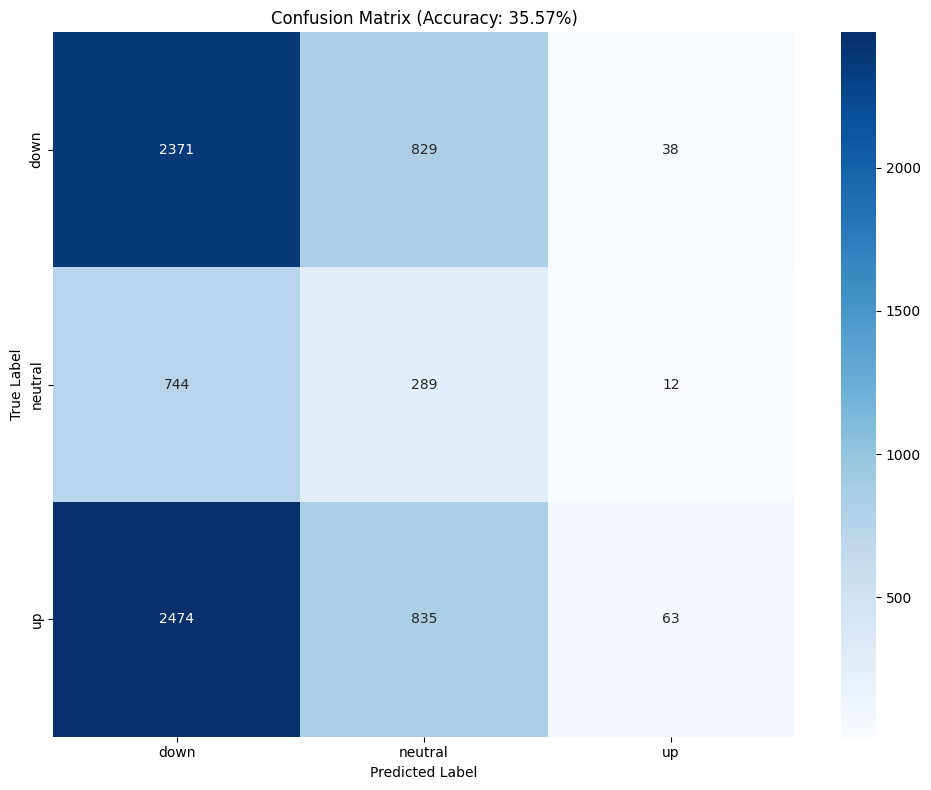


=== PRICE SPACE METRICS (using class medians) ===
RMSE (log-return): 0.020880
MAE (log-return): 0.015899
Это соответствует ошибке в цене ~ 1.59%
Direction Accuracy: 0.4664 (46.64%)


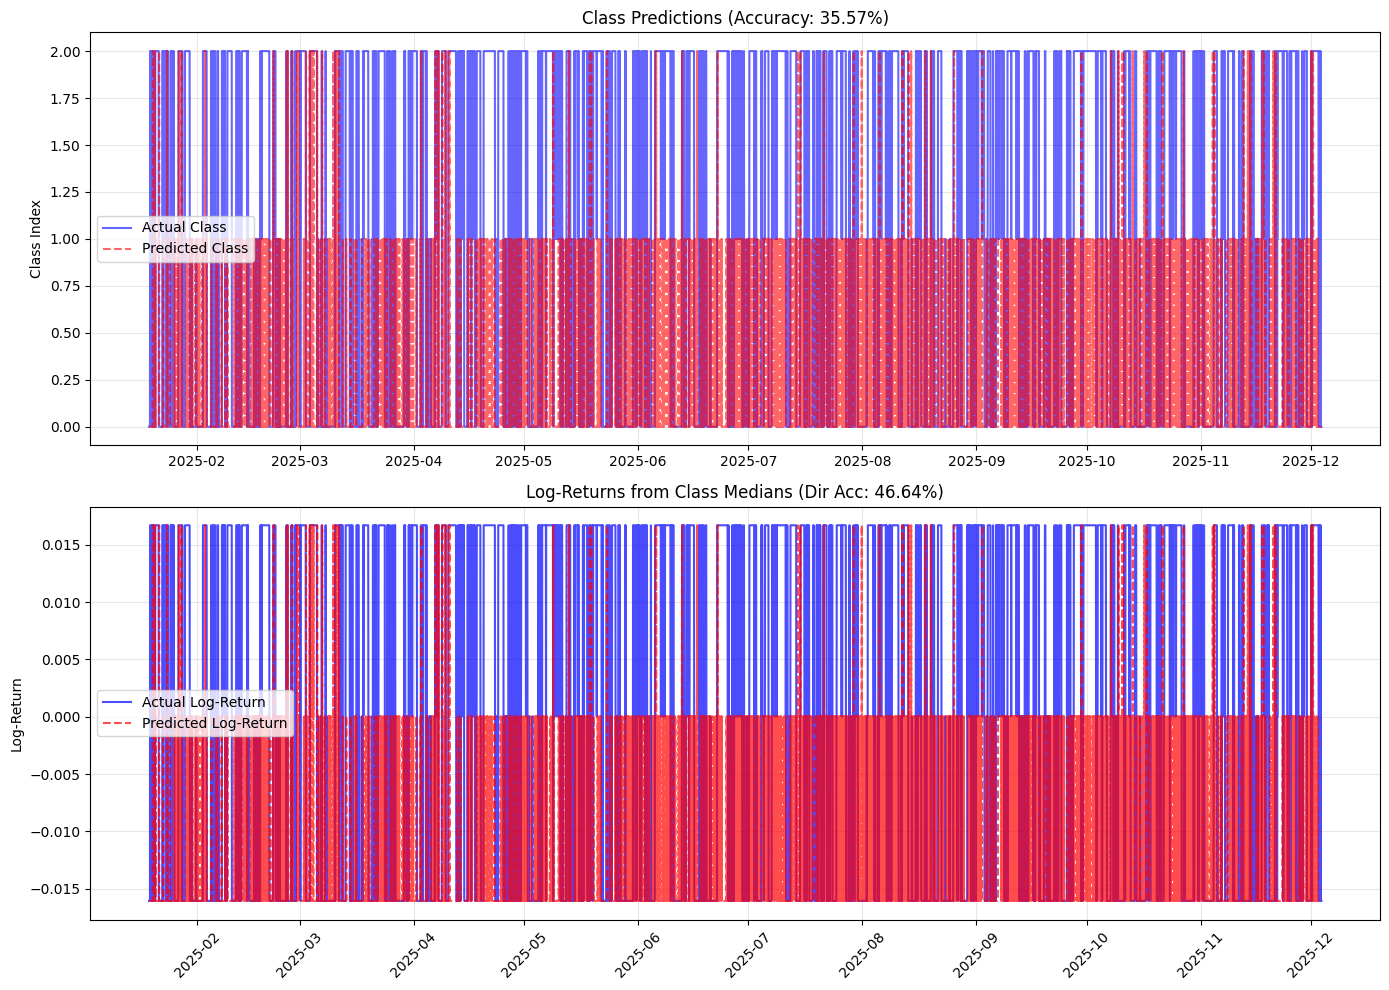

In [35]:
if __name__ == "__main__":
    LOOKBACK = 120
    BATCH_SIZE = 128
    EPOCHS = 50
    D_MODEL = 128
    N_LAYERS = 2
    N_BINS = 3
    CSV_FILE = 'btc_1h_2020-2025_training_sample_with_bins_second.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_classifier.pth'

    data_dict, train_loader, val_loader, test_loader = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE,
        n_bins=N_BINS,
        classification_mode=True,
        force_reprocess=False
    )

    input_dim = data_dict['X_train'].shape[2]
    n_classes = data_dict['n_classes']
    class_labels = data_dict['class_labels']
    class_medians = data_dict['class_medians']

    from sklearn.utils.class_weight import compute_class_weight
    class_weights_np = compute_class_weight('balanced', classes=np.unique(data_dict['y_train']), y=data_dict['y_train'])
    class_weights_tensor = torch.FloatTensor(class_weights_np)
    print(f"Class weights: {class_weights_tensor}")

    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score

    # Flatten: берём последний шаг из каждого окна
    X_train_flat = data_dict['X_train'][:, -1, :]
    X_test_flat = data_dict['X_test'][:, -1, :]
    y_train = data_dict['y_train']
    y_test = data_dict['y_test']

    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_flat, y_train)
    y_pred = clf.predict(X_test_flat)

    print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    model = MambaModel(
        input_dim=input_dim,
        n_classes=n_classes,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        use_mamba=True
    ).to(device)

    history = run_training_classification(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        learning_rate=5e-5,
        early_stop_patience=20,
        model_path=MODEL_PATH,
        class_weights=class_weights_tensor
    )

    if history is not None:
        evaluate_classification(
            model=model,
            test_loader=test_loader,
            class_medians=class_medians,
            class_labels=class_labels,
            time_index=data_dict['time_index']['test'],
            model_path=MODEL_PATH
        )